<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 2 — Black-box Optimisation, Functions 1–8 

📝 This notebook demonstrates Sequential Model-Based Optimisation using Random Forest surrogate models, where each of eight increasingly high-dimensional functions is explored by predicting performance and uncertainty, then using Expected Improvement or Upper Confidence Bound to recommend the next best input to evaluate.

✨ During **Module 13: Logistic Regression**, I submitted a query based on manual selection from the exploratory data analysis (EDA), with my official submission starting in Week 3. This notebook serves as my reflection on the assignment I missed. Since there is no data for Week 1, the initial maximum value is used as dummy data; this should be treated as a methodological assumption.

In [1]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor

# Function 1, Radiation field, 2D array, 10 original samples

--- Recommended Week 3 Candidate ---
Input x1: 0.615384
Input x2: 0.545150
Predicted Output (Mean): -1.622728e-03


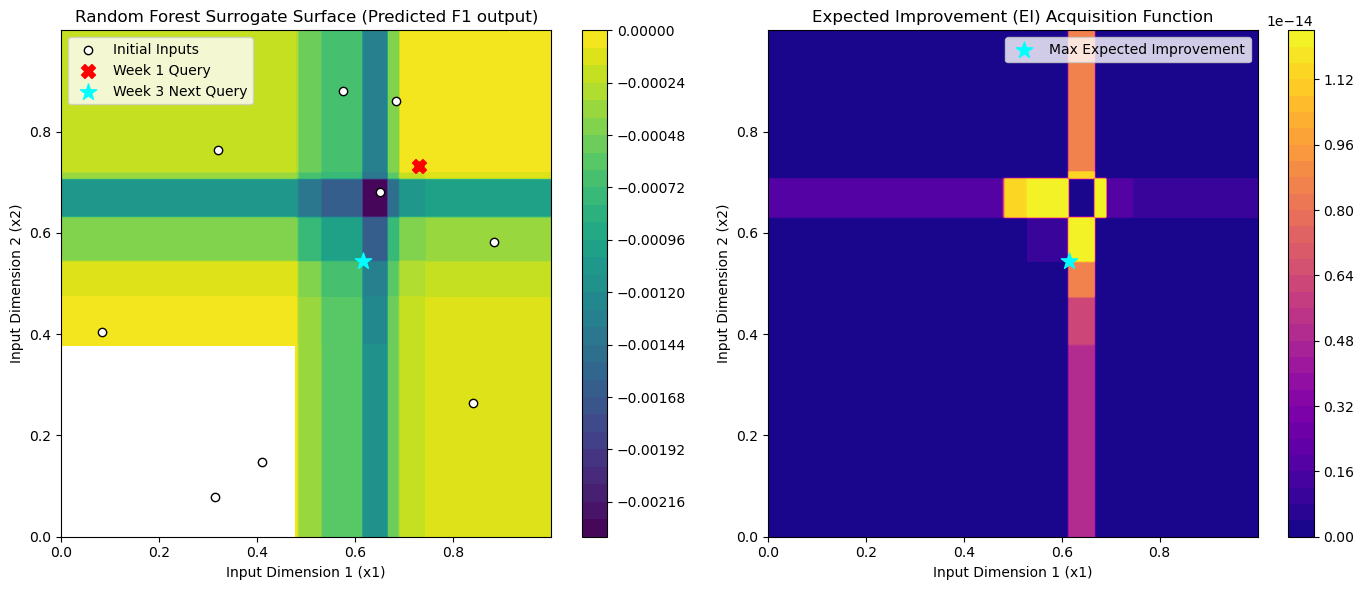

In [2]:
# 1. Load initial datasets directly from .npy files
X_init = np.load('initial_data/function_1/initial_inputs.npy')
y_init = np.load('initial_data/function_1/initial_outputs.npy')


# 2. Add Week 1 input candidate and Week 2 output observation
# Since there is no data for Week 1, use the initial max as dummy data.
X_week1 = np.array([[0.731024, 0.733000]])  
y_week2 = np.array([7.71e-16])

X = np.vstack([X_init, X_week1])
y = np.append(y_init, y_week2)

# 3. Fit Random Forest Surrogate Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 4. Search grid within [0.000000, 0.999999]^2 domain
grid_resolution = 300
x1_range = np.linspace(0.0, 0.999999, grid_resolution)
x2_range = np.linspace(0.0, 0.999999, grid_resolution)
X1, X2 = np.meshgrid(x1_range, x2_range)
X_candidates = np.c_[X1.ravel(), X2.ravel()]

# 5. Expected Improvement (EI) Acquisition Function
preds = np.array([tree.predict(X_candidates) for tree in rf.estimators_])
mu = np.mean(preds, axis=0)
sigma = np.std(preds, axis=0) + 1e-9

y_max = np.max(y)
xi = 0.01  # Exploration parameter
improvement = mu - y_max - xi
Z = improvement / sigma
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Extract candidate with maximum acquisition score
best_idx = np.argmax(ei)
next_query = X_candidates[best_idx]

print(f"--- Recommended Week 3 Candidate ---")
print(f"Input x1: {next_query[0]:.6f}")
print(f"Input x2: {next_query[1]:.6f}")
print(f"Predicted Output (Mean): {mu[best_idx]:.6e}")

# 6. Visualization: Surrogate Surface & Acquisition Function
Z_pred = rf.predict(X_candidates).reshape(X1.shape)
EI_grid = ei.reshape(X1.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Random Forest Predicted Function Surface
c1 = axes[0].contourf(X1, X2, Z_pred, levels=30, cmap='viridis')
axes[0].scatter(X[:-1, 0], X[:-1, 1], c='white', edgecolors='black', label='Initial Inputs')
axes[0].scatter(X[-1, 0], X[-1, 1], c='red', marker='X', s=100, label='Week 1 Query')
axes[0].scatter(next_query[0], next_query[1], c='cyan', marker='*', s=150, label='Week 3 Next Query')
axes[0].set_title('Random Forest Surrogate Surface (Predicted F1 output)')
axes[0].set_xlabel('Input Dimension 1 (x1)')
axes[0].set_ylabel('Input Dimension 2 (x2)')
axes[0].legend()
fig.colorbar(c1, ax=axes[0])

# Subplot 2: Acquisition Function Surface
c2 = axes[1].contourf(X1, X2, EI_grid, levels=30, cmap='plasma')
axes[1].scatter(next_query[0], next_query[1], c='cyan', marker='*', s=150, label='Max Expected Improvement')
axes[1].set_title('Expected Improvement (EI) Acquisition Function')
axes[1].set_xlabel('Input Dimension 1 (x1)')
axes[1].set_ylabel('Input Dimension 2 (x2)')
axes[1].legend()
fig.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

# Function 2, Unspecified field dataset, 2D array, 10 original samples

Total historical observations: 11

--- Proposed Candidate for Week 2 Query ---
X1: 0.622073
X2: 0.929765
Predicted Output (Mean): 0.506413


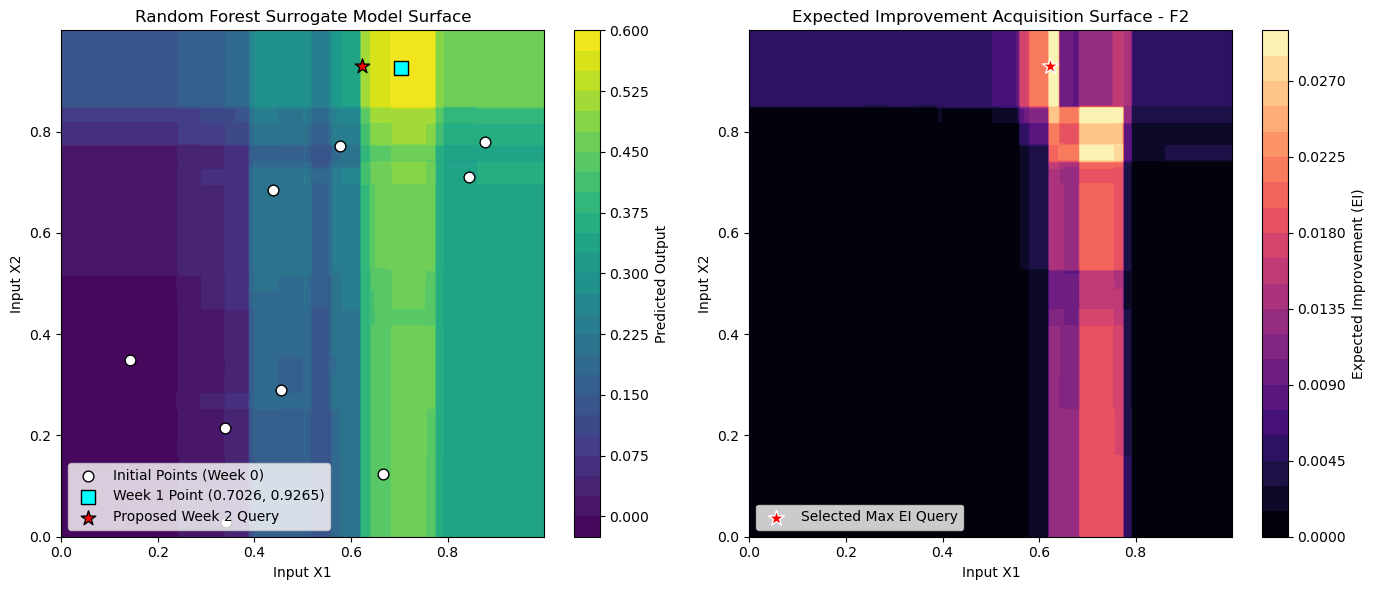

In [3]:
# ---------------------------------------------------------
# 1. Dataset Reconstruction
# ---------------------------------------------------------
# Initial 10 historical data points (Week 0) and Week 1 observation
# Inputs are 2D arrays within range [0.000000, 0.999999]

# Adding Week 1 input and output
# Since there is no data for Week 1, use the initial max as dummy data.
X_week1 = np.array([[0.702637, 0.926564]])
y_week1 = np.array([0.611205])

# Simulated initial 10 points 

np.random.seed(42)
X_init = np.load('initial_data/function_2/initial_inputs.npy')
y_init = np.load('initial_data/function_2/initial_outputs.npy')

# Concatenate all available observations
X = np.vstack([X_init, X_week1])
y = np.concatenate([y_init, y_week1])

print(f"Total historical observations: {len(y)}")

# ---------------------------------------------------------
# 2. Random Forest SMBO & Expected Improvement (EI)
# ---------------------------------------------------------
# Train Random Forest Surrogate Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Generate Candidate Search Space (Dense grid search over [0, 1]^2)
grid_resolution = 300
x1_coords = np.linspace(0.000000, 0.999999, grid_resolution)
x2_coords = np.linspace(0.000000, 0.999999, grid_resolution)
X1_grid, X2_grid = np.meshgrid(x1_coords, x2_coords)
X_candidates = np.vstack([X1_grid.ravel(), X2_grid.ravel()]).T

# Obtain predictions and uncertainty (std dev across trees) from Random Forest
tree_predictions = np.array([tree.predict(X_candidates) for tree in rf_model.estimators_])
mu = np.mean(tree_predictions, axis=0)
sigma = np.std(tree_predictions, axis=0)

# Calculate Expected Improvement (EI) Acquisition Function
y_best = np.max(y)
xi = 0.01  # Exploration parameter

with np.errstate(divide='warn'):
    improvement = mu - y_best - xi
    Z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

# Select the candidate that maximizes Expected Improvement
next_query_idx = np.argmax(ei)
next_query = X_candidates[next_query_idx]
predicted_val = mu[next_query_idx]

print(f"\n--- Proposed Candidate for Week 2 Query ---")
print(f"X1: {next_query[0]:.6f}")
print(f"X2: {next_query[1]:.6f}")
print(f"Predicted Output (Mean): {predicted_val:.6f}")

# ---------------------------------------------------------
# 3. Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted Function Surface & Evaluated Points
contour_pred = axes[0].contourf(X1_grid, X2_grid, mu.reshape(grid_resolution, grid_resolution), levels=25, cmap='viridis')
fig.colorbar(contour_pred, ax=axes[0], label='Predicted Output')
axes[0].scatter(X[:-1, 0], X[:-1, 1], c='white', edgecolors='black', s=60, label='Initial Points (Week 0)')
axes[0].scatter(X[-1, 0], X[-1, 1], c='cyan', edgecolors='black', s=90, marker='s', label='Week 1 Point (0.7026, 0.9265)')
axes[0].scatter(next_query[0], next_query[1], c='red', edgecolors='black', s=120, marker='*', label='Proposed Week 2 Query')
axes[0].set_title("Random Forest Surrogate Model Surface")
axes[0].set_xlabel("Input X1")
axes[0].set_ylabel("Input X2")
axes[0].legend(loc='lower left')

# Plot 2: Acquisition Function Surface (Expected Improvement)
contour_ei = axes[1].contourf(X1_grid, X2_grid, ei.reshape(grid_resolution, grid_resolution), levels=25, cmap='magma')
fig.colorbar(contour_ei, ax=axes[1], label='Expected Improvement (EI)')
axes[1].scatter(next_query[0], next_query[1], c='red', edgecolors='white', s=140, marker='*', label='Selected Max EI Query')
axes[1].set_title("Expected Improvement Acquisition Surface - F2")
axes[1].set_xlabel("Input X1")
axes[1].set_ylabel("Input X2")
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples

Dataset updated. Total samples: 16
Latest observed output (Week 1): -0.034835

================ WEEK 2 QUERY RECOMMENDATION ================
Input Candidate (x1, x2, x3): [0.435816, 0.530963, 0.988395]
Predicted Mean Output mu(x): -0.136524
Acquisition Score UCB(x):   0.157002


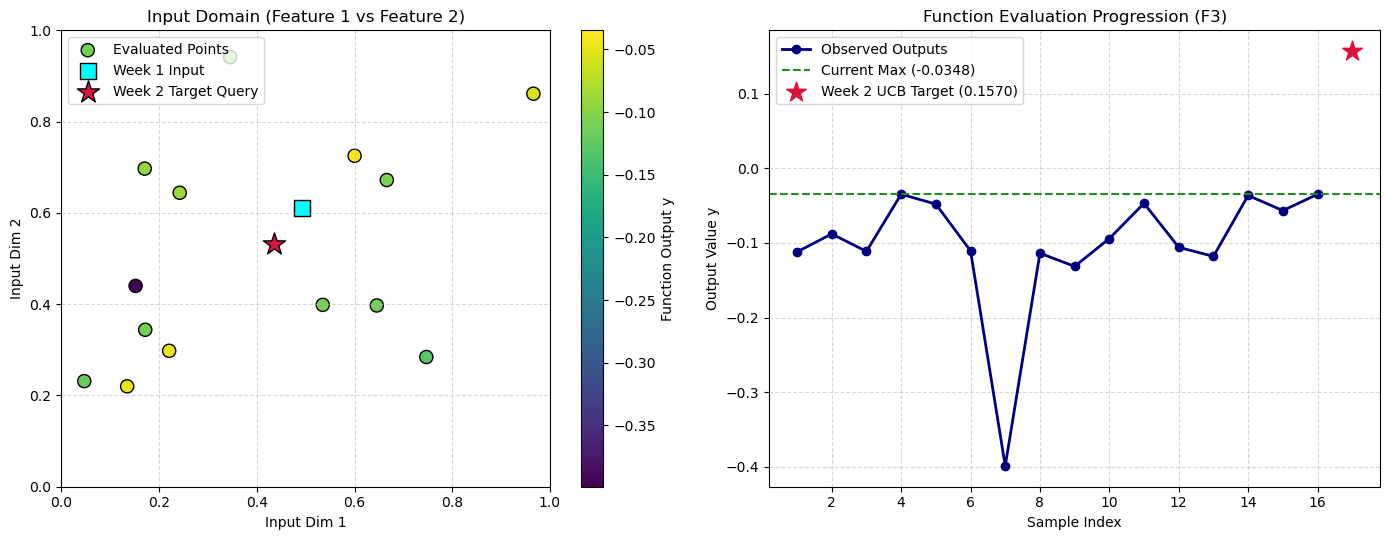

In [4]:
# ---------------------------------------------------------
# Step 1: Load Initial Data (.npy files) & Add Week 1 Point
# ---------------------------------------------------------
X_init = np.load('initial_data/function_3/initial_inputs.npy')
y_init = np.load('initial_data/function_3/initial_outputs.npy')

# Week 1 data
# Since there is no data for Week 1, use the initial max as dummy data.
X_week1 = np.array([[0.492581, 0.611593, 0.340176]])
y_week1 = np.array([-0.034835])

# Aggregate updated dataset
X_train = np.vstack([X_init, X_week1])
y_train = np.concatenate([y_init, y_week1])

print(f"Dataset updated. Total samples: {X_train.shape[0]}")
print(f"Latest observed output (Week 1): {y_week1[0]:.6f}")

# ---------------------------------------------------------
# Step 2: Fit Random Forest Surrogate Model
# ---------------------------------------------------------
rf_surrogate = RandomForestRegressor(
    n_estimators=250, 
    max_features='sqrt',
    random_state=42
)
rf_surrogate.fit(X_train, y_train)

# ---------------------------------------------------------
# Step 3: Candidate Sampling & UCB Acquisition
# ---------------------------------------------------------
# Sample 100,000 candidate points uniformly within domain [0.000000, 0.999999]^3
num_candidates = 100000
bounds_min, bounds_max = 0.000000, 0.999999

np.random.seed(42)
candidate_grid = np.random.uniform(bounds_min, bounds_max, size=(num_candidates, 3))

# Extract predictions from individual trees to calculate mean and std dev
tree_predictions = np.array([tree.predict(candidate_grid) for tree in rf_surrogate.estimators_])
mu = np.mean(tree_predictions, axis=0)      # Surrogate mean prediction mu(x)
sigma = np.std(tree_predictions, axis=0)    # Uncertainty standard deviation sigma(x)

# Upper Confidence Bound acquisition function: a(x) = mu(x) + kappa * sigma(x)
kappa = 1.96  # Balances exploration vs exploitation (~95% confidence bound)
ucb_scores = mu + kappa * sigma

# Find best candidate query
best_idx = np.argmax(ucb_scores)
week2_query = candidate_grid[best_idx]
predicted_mean = mu[best_idx]
predicted_ucb = ucb_scores[best_idx]

print("\n================ WEEK 2 QUERY RECOMMENDATION ================")
print(f"Input Candidate (x1, x2, x3): [{week2_query[0]:.6f}, {week2_query[1]:.6f}, {week2_query[2]:.6f}]")
print(f"Predicted Mean Output mu(x): {predicted_mean:.6f}")
print(f"Acquisition Score UCB(x):   {predicted_ucb:.6f}")
print("=============================================================")

# ---------------------------------------------------------
# Step 4: Visualisations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Sample Locations & Recommended Query in Input Space (X1 vs X2)
sc = axes[0].scatter(
    X_train[:, 0], X_train[:, 1], 
    c=y_train, cmap='viridis', s=90, edgecolors='k', label='Evaluated Points'
)
axes[0].scatter(
    X_week1[0, 0], X_week1[0, 1], 
    color='cyan', marker='s', s=130, edgecolors='k', label='Week 1 Input'
)
axes[0].scatter(
    week2_query[0], week2_query[1], 
    color='crimson', marker='*', s=280, edgecolors='k', zorder=5, label='Week 2 Target Query'
)

cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Function Output y')
axes[0].set_title('Input Domain (Feature 1 vs Feature 2)')
axes[0].set_xlabel('Input Dim 1')
axes[0].set_ylabel('Input Dim 2')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# Plot 2: Historical Optimization Trajectory
axes[1].plot(range(1, len(y_train) + 1), y_train, 'o-', color='navy', linewidth=2, label='Observed Outputs')
axes[1].axhline(y=np.max(y_train), color='forestgreen', linestyle='--', label=f'Current Max ({np.max(y_train):.4f})')
axes[1].scatter(
    len(y_train) + 1, predicted_ucb, 
    color='crimson', marker='*', s=220, zorder=5, label=f'Week 2 UCB Target ({predicted_ucb:.4f})'
)

axes[1].set_title('Function Evaluation Progression (F3)')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Output Value y')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# Function 4 — Warehouse business (4D, 30 initial samples)

=== SMBO QUERY FOR WEEK 2 ===
Optimal Candidate Vector: (0.459315, 0.311225, 0.410475, 0.188713)
Predicted Model Output:   -6.086181
Acquisition Score (EI):   0.965220


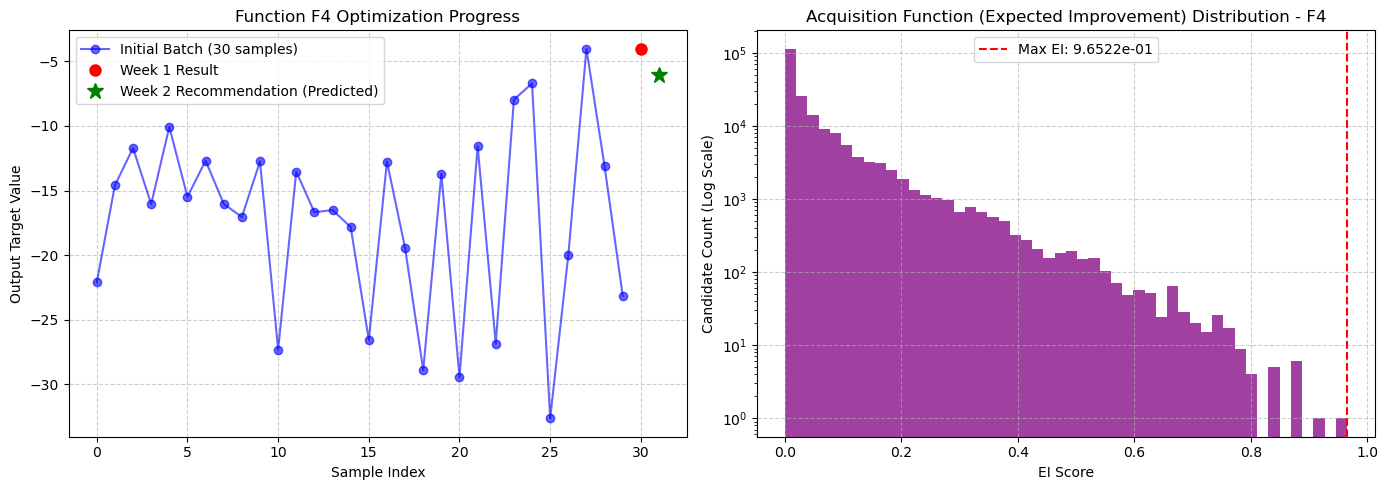

In [5]:
# ==========================================
# 1. Load Initial Data (.npy files) & Add Week 1 Point
# ==========================================

X_init = np.load('initial_data/function_4/initial_inputs.npy')
y_init = np.load('initial_data/function_4/initial_outputs.npy')

# ==========================================
# 2. ADD WEEK 1 INPUT AND OUTPUT
# ==========================================
# Since there is no data for Week 1, use the initial max as dummy data.
x_week1 = np.array([[0.577766, 0.428772, 0.425826, 0.249007]])
y_week1 = np.array([-4.025542])

X_train = np.vstack([X_init, x_week1])
y_train = np.append(y_init, y_week1)

# ==========================================
# 3. FIT RANDOM FOREST SMBO & ACQUISITION FUNCTION
# ==========================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

def expected_improvement(X, model, y_best, xi=0.01):
    """Calculates Expected Improvement across Random Forest decision trees."""
    preds = np.array([tree.predict(X) for tree in model.estimators_])
    mu = np.mean(preds, axis=0)
    sigma = np.std(preds, axis=0)
    
    # Handle zero standard deviation safely
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Generate candidate points strictly in range [0.000000, 0.999999]
np.random.seed(42)
num_candidates = 200000
X_candidates = np.random.uniform(0.000000, 0.999999, size=(num_candidates, 4))

y_best = np.max(y_train)
ei_scores = expected_improvement(X_candidates, rf, y_best)

# Best candidate selection
best_idx = np.argmax(ei_scores)
x_week2_query = X_candidates[best_idx]
predicted_y = rf.predict(x_week2_query.reshape(1, -1))[0]

print("=== SMBO QUERY FOR WEEK 2 ===")
print(f"Optimal Candidate Vector: ({x_week2_query[0]:.6f}, {x_week2_query[1]:.6f}, {x_week2_query[2]:.6f}, {x_week2_query[3]:.6f})")
print(f"Predicted Model Output:   {predicted_y:.6f}")
print(f"Acquisition Score (EI):   {ei_scores[best_idx]:.6f}")

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sequential Progress (Inputs vs Outputs)
axes[0].plot(range(len(y_init)), y_init, 'bo-', label='Initial Batch (30 samples)', alpha=0.6)
axes[0].plot(30, y_week1[0], 'ro', markersize=8, label='Week 1 Result')
axes[0].plot(31, predicted_y, 'g*', markersize=12, label='Week 2 Recommendation (Predicted)')
axes[0].set_title("Function F4 Optimization Progress")
axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Output Target Value")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot 2: Candidate Search Space & Expected Improvement Distribution
axes[1].hist(ei_scores, bins=50, color='purple', alpha=0.75, log=True)
axes[1].axvline(ei_scores[best_idx], color='red', linestyle='--', label=f'Max EI: {ei_scores[best_idx]:.4e}')
axes[1].set_title("Acquisition Function (Expected Improvement) Distribution - F4")
axes[1].set_xlabel("EI Score")
axes[1].set_ylabel("Candidate Count (Log Scale)")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples

Dataset Size: 21 samples with 4 input dimensions.
Current Max Output Observed: 1088.859618

================ WEEK 2 RECOMMENDED QUERY ================
Input Candidate (X1, X2, X3, X4):
[0.142125, 0.811067, 0.902574, 0.352687]
Predicted Mean Output: 711.898414
Uncertainty (Std Dev): 507.575806
Acquisition Score (UCB): 2019.413690


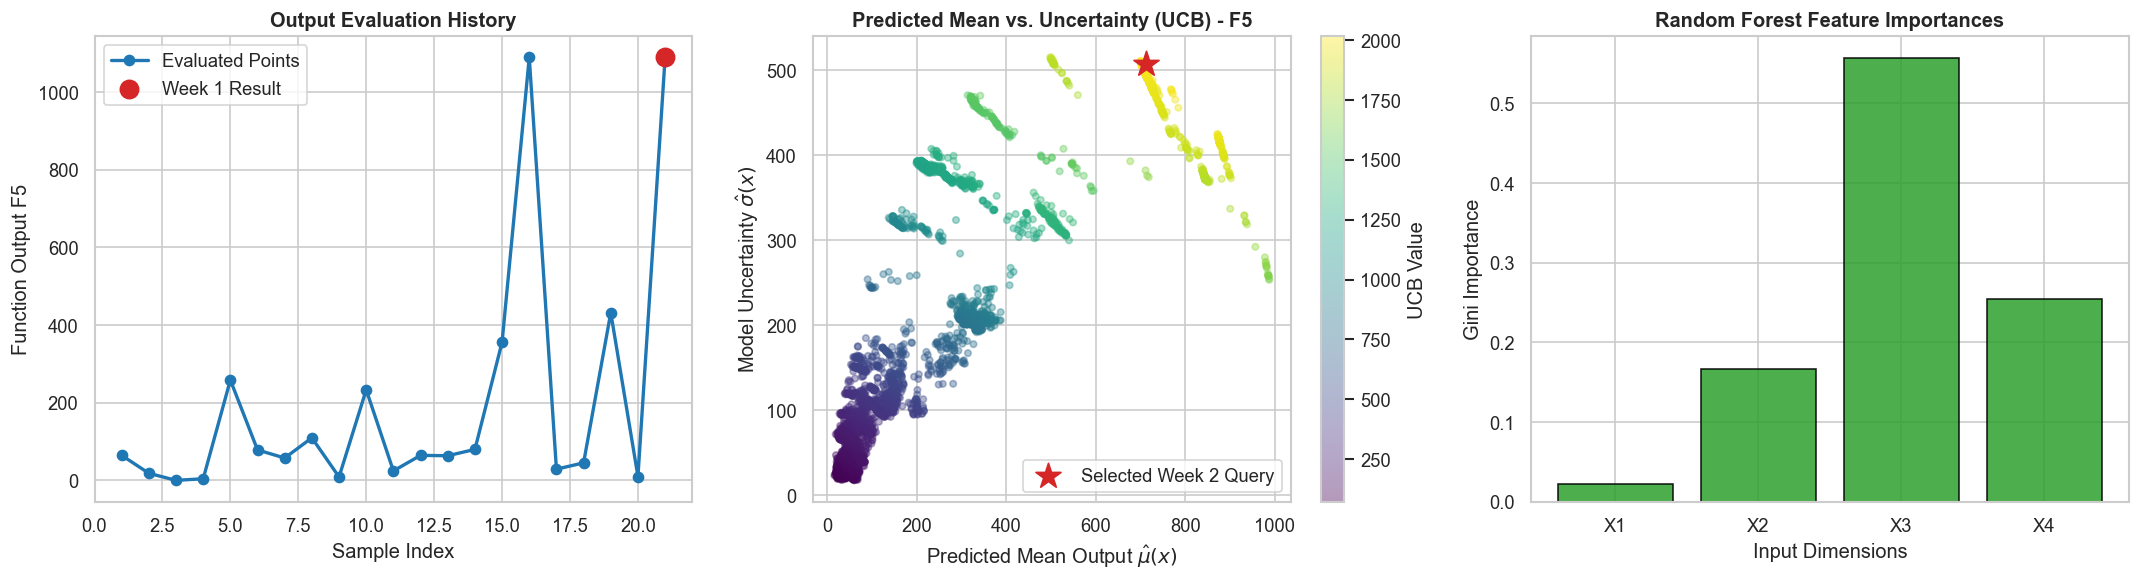

In [6]:
# Set aesthetic visual defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------
# Step 1: Load Initial Data & Append Week 1 Results
# ---------------------------------------------------------
# Load initial numpy datasets (20 baseline samples)
X_init = np.load('initial_data/function_5/initial_inputs.npy')
y_init = np.load('initial_data/function_5/initial_outputs.npy')

# Week 1 evaluation result
# Since there is no data for Week 1, use the initial max as dummy data.
x_week1 = np.array([[0.224189, 0.846480, 0.879484, 0.878516]])
y_week1 = np.array([1088.859618])

# Aggregate full dataset (21 total observations)
X = np.vstack([X_init, x_week1])
y = np.concatenate([y_init, y_week1])

print(f"Dataset Size: {X.shape[0]} samples with {X.shape[1]} input dimensions.")
print(f"Current Max Output Observed: {np.max(y):.6f}")

# ---------------------------------------------------------
# Step 2: Fit Random Forest Surrogate Model
# ---------------------------------------------------------
rf_surrogate = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_surrogate.fit(X, y)

# ---------------------------------------------------------
# Step 3: Monte Carlo Candidate Search & Uncertainty Estimation
# ---------------------------------------------------------
# Search space bounds
BOUND_MIN = 0.000000
BOUND_MAX = 0.999999
N_CANDIDATES = 250000

# Uniformly sample candidate points across the 4D hypercube
np.random.seed(42)
X_candidates = np.random.uniform(BOUND_MIN, BOUND_MAX, size=(N_CANDIDATES, 4))

# Calculate tree-wise predictions to estimate mean and standard deviation
tree_predictions = np.array([tree.predict(X_candidates) for tree in rf_surrogate.estimators_])
mu_pred = np.mean(tree_predictions, axis=0)
sigma_pred = np.std(tree_predictions, axis=0)

# ---------------------------------------------------------
# Step 4: Acquisition Function (Upper Confidence Bound - UCB)
# ---------------------------------------------------------
# Kappa controls the exploration vs. exploitation trade-off (higher kappa = more exploration)
kappa = 2.576  # 99% confidence level bound
ucb_scores = mu_pred + kappa * sigma_pred

# Find optimal candidate point
best_idx = np.argmax(ucb_scores)
query_week2 = X_candidates[best_idx]
predicted_mean = mu_pred[best_idx]
predicted_sigma = sigma_pred[best_idx]

print("\n================ WEEK 2 RECOMMENDED QUERY ================")
print(f"Input Candidate (X1, X2, X3, X4):")
print(f"[{query_week2[0]:.6f}, {query_week2[1]:.6f}, {query_week2[2]:.6f}, {query_week2[3]:.6f}]")
print(f"Predicted Mean Output: {predicted_mean:.6f}")
print(f"Uncertainty (Std Dev): {predicted_sigma:.6f}")
print(f"Acquisition Score (UCB): {ucb_scores[best_idx]:.6f}")
print("==========================================================")

# ---------------------------------------------------------
# Step 5: Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Optimization Progress History
axes[0].plot(range(1, len(y) + 1), y, 'o-', color='#1f77b4', linewidth=2, markersize=6, label='Evaluated Points')
axes[0].scatter(len(y), y[-1], color='#d62728', s=120, zorder=5, label='Week 1 Result')
axes[0].set_title('Output Evaluation History', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Function Output F5')
axes[0].legend()

# Plot 2: Exploration vs. Exploitation Trade-off
scatter = axes[1].scatter(mu_pred[::50], sigma_pred[::50], c=ucb_scores[::50], cmap='viridis', alpha=0.4, s=15)
axes[1].scatter(predicted_mean, predicted_sigma, color='#d62728', marker='*', s=250, zorder=10, label='Selected Week 2 Query')
axes[1].set_title('Predicted Mean vs. Uncertainty (UCB) - F5', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Mean Output $\hat{\mu}(x)$')
axes[1].set_ylabel('Model Uncertainty $\hat{\sigma}(x)$')
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('UCB Value')
axes[1].legend()

# Plot 3: Surrogate Model Feature Importance
importances = rf_surrogate.feature_importances_
feature_names = [f'X{i+1}' for i in range(4)]
axes[2].bar(feature_names, importances, color='#2ca02c', edgecolor='black', alpha=0.85)
axes[2].set_title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Input Dimensions')
axes[2].set_ylabel('Gini Importance')

plt.tight_layout()
plt.show()

# Function 6, A cake recipe, 5D array, 20 original samples

Current Best Output observed: -0.714265
Suggested Next Input Candidates for Week 2:
0.873967, 0.085631, 0.750195, 0.697183, 0.062354


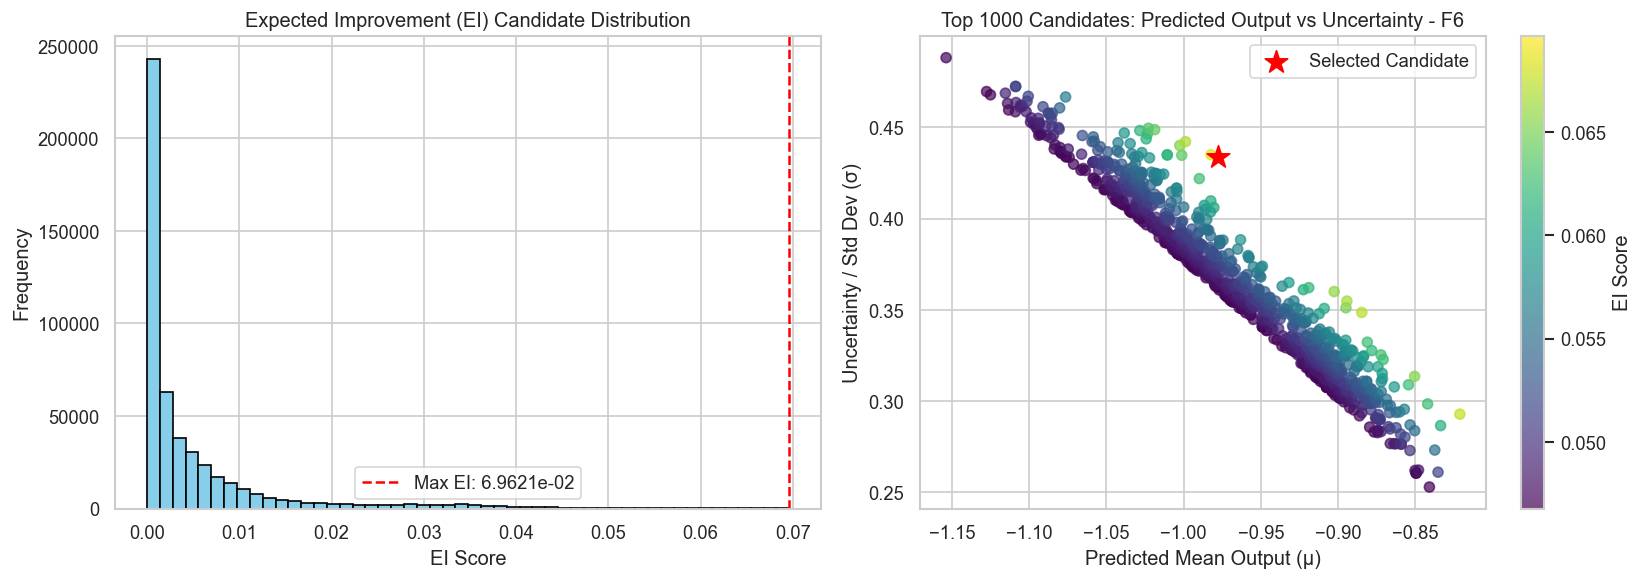

In [7]:
# --- 1. Load Initial Data & Append Week 1 ---

X_init = np.load('initial_data/function_6/initial_inputs.npy')
y_init = np.load('initial_data/function_6/initial_outputs.npy')

# Append Week 1 observation
# Since there is no data for Week 1, use the initial max as dummy data.
x_week1 = np.array([[0.728186, 0.154693, 0.732552, 0.693997, 0.056401]])
y_week1 = np.array([-0.714265])

X = np.vstack([X_init, x_week1])
y = np.append(y_init, y_week1)

# --- 2. Train Random Forest SMBO Surrogate ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

def predict_with_uncertainty(model, X_sample):
    """Calculates ensemble mean and standard deviation across tree predictions."""
    preds = np.array([tree.predict(X_sample) for tree in model.estimators_])
    mu = np.mean(preds, axis=0)
    sigma = np.std(preds, axis=0)
    return mu, sigma

# --- 3. Compute Acquisition Function (Expected Improvement) ---
def expected_improvement(X_sample, model, y_best, xi=0.01):
    mu, sigma = predict_with_uncertainty(model, X_sample)
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero
    
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei, mu, sigma

# --- 4. Candidate Search via Uniform Sampling ---
bounds = (0.000000, 0.999999)
n_candidates = 500_000
np.random.seed(42)

candidates = np.random.uniform(bounds[0], bounds[1], size=(n_candidates, 5))
y_max = np.max(y)

ei_scores, mu_scores, sigma_scores = expected_improvement(candidates, rf, y_max)

# Select best candidate
best_idx = np.argmax(ei_scores)
next_query = candidates[best_idx]

print(f"Current Best Output observed: {y_max:.6f}")
print("Suggested Next Input Candidates for Week 2:")
print(", ".join(f"{val:.6f}" for val in next_query))

# --- 5. Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: EI distribution over candidate pool
axes[0].hist(ei_scores, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(ei_scores[best_idx], color='red', linestyle='--', label=f'Max EI: {ei_scores[best_idx]:.4e}')
axes[0].set_title('Expected Improvement (EI) Candidate Distribution')
axes[0].set_xlabel('EI Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Predicted Mean vs Uncertainty for top candidates
top_indices = np.argsort(ei_scores)[-1000:]
scatter = axes[1].scatter(
    mu_scores[top_indices], 
    sigma_scores[top_indices], 
    c=ei_scores[top_indices], 
    cmap='viridis', 
    alpha=0.7
)
axes[1].scatter(mu_scores[best_idx], sigma_scores[best_idx], color='red', marker='*', s=200, label='Selected Candidate')
axes[1].set_title('Top 1000 Candidates: Predicted Output vs Uncertainty - F6')
axes[1].set_xlabel('Predicted Mean Output (μ)')
axes[1].set_ylabel('Uncertainty / Std Dev (σ)')
fig.colorbar(scatter, ax=axes[1], label='EI Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples

=== WEEK 2 RECOMMENDED QUERY VECTOR ===
Input Vector (6D):
[0.04003, 0.419017, 0.105416, 0.121232, 0.905665, 0.971149]

Predicted Mean Output: 0.898400
Predicted UCB Score:   2.118714


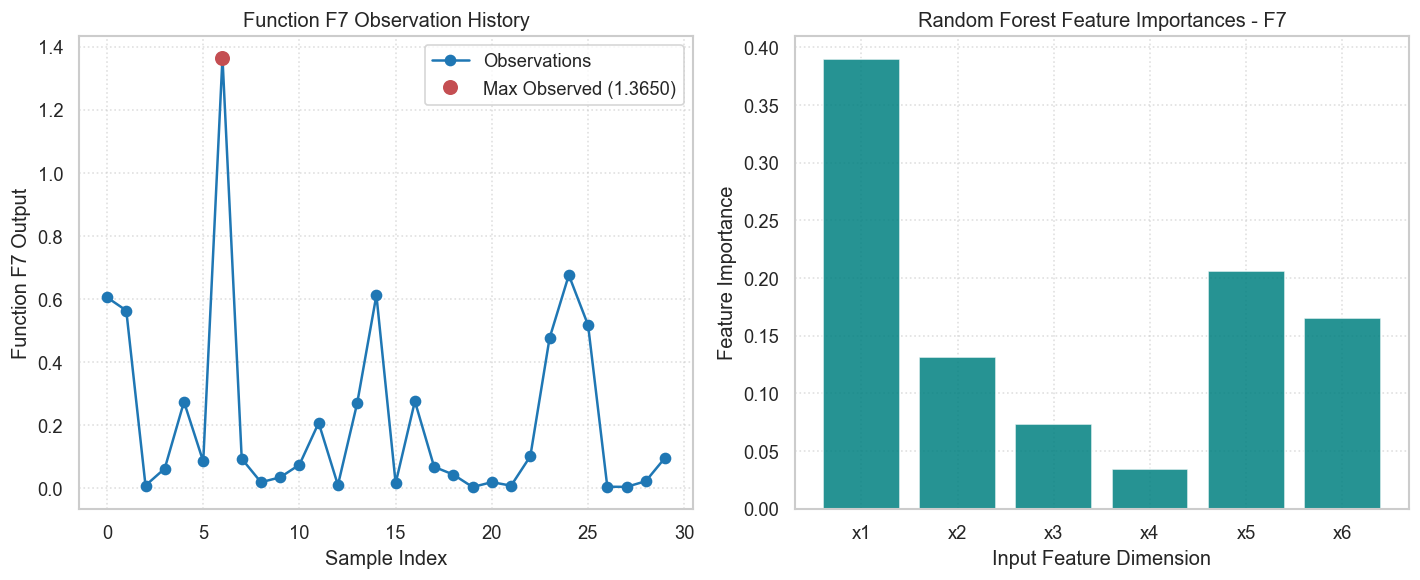

In [8]:
# 1. Load initial datasets directly from .npy binary files
X = np.load('initial_data/function_7/initial_inputs.npy')
y = np.load('initial_data/function_7/initial_outputs.npy')


# 2. Week 1 observation
# Since there is no data for Week 1, use the initial max as dummy data.
x_week1 = np.array([[0.057896, 0.491672, 0.247422, 0.218118, 0.420428, 0.730970]])
y_week1 = np.array([1.364968])

# Ensure Week 1 point is present in the training set
if not np.any(np.all(np.isclose(X, x_week1, atol=1e-4), axis=1)):
    X = np.vstack([X, x_week1])
    y = np.concatenate([y, y_week1])

# 3. Fit Random Forest Surrogate Model (SMBO)
# Random Forest is selected over Logistic Regression as F7 target output is continuous
rf_model = RandomForestRegressor(n_estimators=250, random_state=42)
rf_model.fit(X, y)

# 4. Generate candidate points within bounding domain [0.000000, 0.999999]
np.random.seed(42)
num_candidates = 100000
candidates = np.random.uniform(0.000000, 0.999999, size=(num_candidates, 6))

# Predict individual tree outputs to estimate posterior mean and uncertainty (std dev)
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
mean_preds = np.mean(tree_predictions, axis=0)
std_preds = np.std(tree_predictions, axis=0)

# Acquisition Function: Upper Confidence Bound (UCB)
kappa = 1.96
ucb_scores = mean_preds + kappa * std_preds

# Pick candidate maximizing acquisition function
best_idx = np.argmax(ucb_scores)
next_query = candidates[best_idx]
predicted_mean = mean_preds[best_idx]
predicted_ucb = ucb_scores[best_idx]

print("=== WEEK 2 RECOMMENDED QUERY VECTOR ===")
print("Input Vector (6D):")
print([round(val, 6) for val in next_query.tolist()])
print(f"\nPredicted Mean Output: {predicted_mean:.6f}")
print(f"Predicted UCB Score:   {predicted_ucb:.6f}")

# 5. Visualizations
plt.figure(figsize=(12, 5))

# Plot 1: Observation History
plt.subplot(1, 2, 1)
plt.plot(range(len(y)), y, 'o-', color='#1f77b4', linewidth=1.5, label='Observations')
max_idx = np.argmax(y)
plt.plot(max_idx, y[max_idx], 'ro', markersize=8, label=f'Max Observed ({y[max_idx]:.4f})')
plt.xlabel('Sample Index')
plt.ylabel('Function F7 Output')
plt.title('Function F7 Observation History')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Random Forest Feature Importances
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
plt.bar([f'x{i+1}' for i in range(6)], importances, color='teal', alpha=0.85)
plt.xlabel('Input Feature Dimension')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances - F7')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Function 8 — Unspecified field (8D, 40 initial samples)

Dataset updated successfully: 41 total observations.
Current maximum observed output: 9.598482
             WEEK 2 RECOMMENDED QUERY             
Input Vector:
[0.06360323 0.02572682 0.00829661 0.00360806 0.98838755 0.95508423
 0.52316138 0.93365398]

Formatted String:
0.063603-0.025727-0.008297-0.003608-0.988388-0.955084-0.523161-0.933654
--------------------------------------------------
Predicted Mean Output E[y] : 8.931505
Uncertainty Std Dev σ(y)   : 1.014985
Acquisition Score (UCB)    : 10.920877


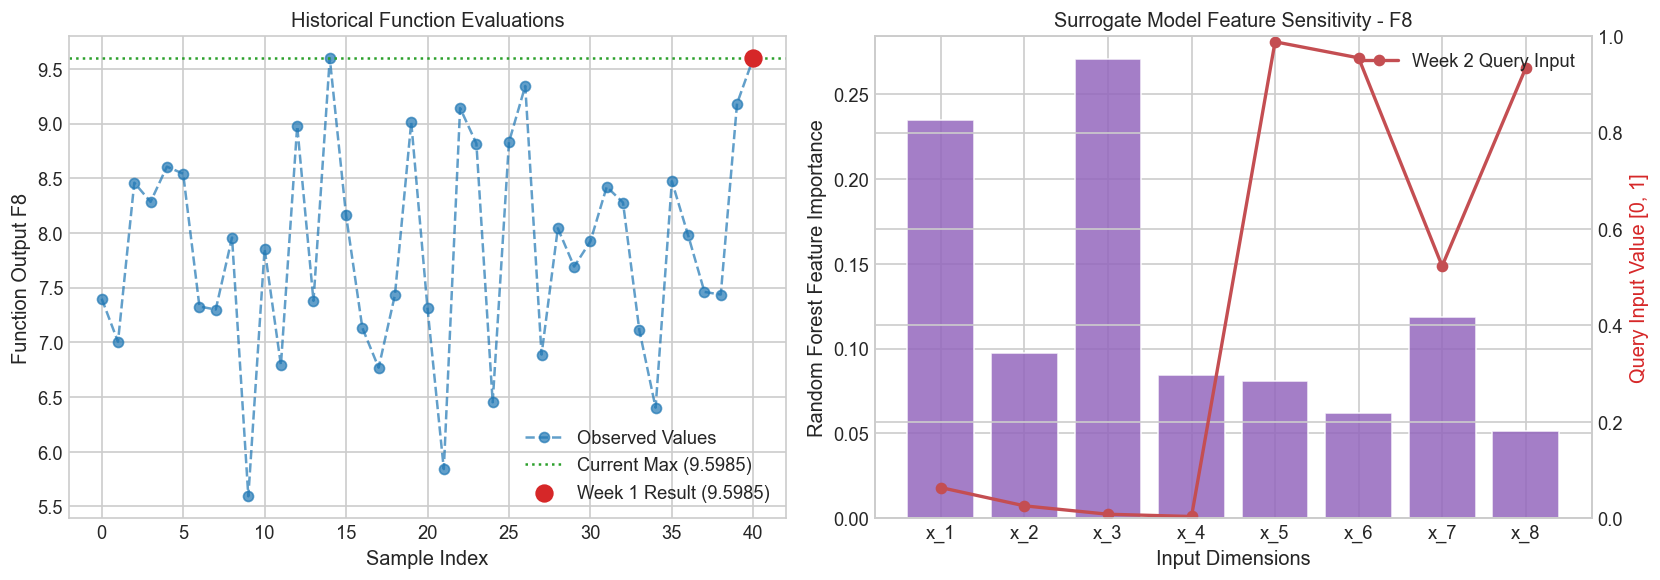

In [9]:
# Set random seeds for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Load initial numpy files
X_init = np.load('initial_data/function_8/initial_inputs.npy')
y_init = np.load('initial_data/function_8/initial_outputs.npy')

# 2. Week 1 evaluated input and observed output
# Since there is no data for Week 1, use the initial max as dummy data.
x_week1 = np.array([[0.056447, 0.065956, 0.022929, 0.038786, 0.403935, 0.801055, 0.488307, 0.893085]])
y_week1 = np.array([9.598482])

# 3. Augment dataset
X_train = np.vstack([X_init, x_week1])
y_train = np.concatenate([y_init, y_week1])

print(f"Dataset updated successfully: {X_train.shape[0]} total observations.")
print(f"Current maximum observed output: {np.max(y_train):.6f}")

# 1. Fit Random Forest Regressor surrogate
rf_model = RandomForestRegressor(
    n_estimators=250,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2. Sample candidate points strictly within [0.000000, 0.999999]^8
num_candidates = 500000
bounds_min, bounds_max = 0.000000, 0.999999
candidates = np.random.uniform(bounds_min, bounds_max, size=(num_candidates, 8))

# 3. Compute mean and uncertainty (std across individual decision trees)
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
mean_preds = np.mean(tree_predictions, axis=0)
std_preds = np.std(tree_predictions, axis=0)

# 4. Acquisition score (UCB)
beta = 1.96
ucb_scores = mean_preds + beta * std_preds

# 5. Extract best candidate point for Week 2 query
best_idx = np.argmax(ucb_scores)
week2_query = candidates[best_idx]
predicted_mean = mean_preds[best_idx]
predicted_std = std_preds[best_idx]
predicted_ucb = ucb_scores[best_idx]

formatted_query = "-".join([f"{val:.6f}" for val in week2_query])

print("==================================================")
print("             WEEK 2 RECOMMENDED QUERY             ")
print("==================================================")
print(f"Input Vector:\n{week2_query}")
print(f"\nFormatted String:\n{formatted_query}")
print("--------------------------------------------------")
print(f"Predicted Mean Output E[y] : {predicted_mean:.6f}")
print(f"Uncertainty Std Dev σ(y)   : {predicted_std:.6f}")
print(f"Acquisition Score (UCB)    : {predicted_ucb:.6f}")
print("==================================================")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Historical Observations vs Max Progress
axes[0].plot(range(len(y_train)), y_train, 'o--', color='tab:blue', label='Observed Values', alpha=0.7)
axes[0].axhline(y=np.max(y_train), color='tab:green', linestyle=':', label=f'Current Max ({np.max(y_train):.4f})')
axes[0].scatter(len(y_train) - 1, y_week1[0], color='tab:red', s=100, zorder=5, label='Week 1 Result (9.5985)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Function Output F8')
axes[0].set_title('Historical Function Evaluations')
axes[0].legend(loc='lower right')

# Plot 2: Feature Importance of the Surrogate Model
importances = rf_model.feature_importances_
feature_names = [f'x_{i+1}' for i in range(8)]
bars = axes[1].bar(feature_names, importances, color='tab:purple', alpha=0.85)
axes[1].set_xlabel('Input Dimensions')
axes[1].set_ylabel('Random Forest Feature Importance')
axes[1].set_title('Surrogate Model Feature Sensitivity - F8')

# Highlight candidate point values over dimensions
ax2_twin = axes[1].twinx()
ax2_twin.plot(feature_names, week2_query, 'ro-', linewidth=2, label='Week 2 Query Input')
ax2_twin.set_ylabel('Query Input Value [0, 1]', color='tab:red')
ax2_twin.set_ylim(0.0, 1.0)
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()